# How to Increase the Profitability of WineNot?

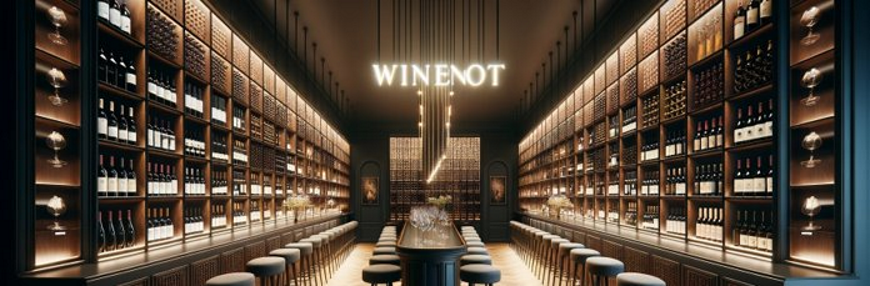

# Table of Contents

In [ ]:
# Create table of contents using a dictionary

table_of_contents = {
    'Introduction': None,
    '1. Data Preparation, Reading and Processing': {
        '1.1. Data Normalization': None
    },
    '2. Statistical Data Analysis': {
        '2.1. Dimensionality Reduction': {
            '2.1.1. Correlation Matrix': None
        }
    },
    '3. Data Modelling': {
        '3.1. Elbow Curve': None,
        '3.2. K-means': None,
        '3.3. Silhouette Plot': None,
        '3.4. Self-Organizing Maps': None
    },
    '4. Cluster Interpretation': {
        '4.1. Decision Tree': None,
        '4.2. ChatGPT Survey': None
    },
    '5. Iterative K-means': None
}

# Function to display the table of contents
def display_table_of_contents(table_of_contents, level=0):
    for key, value in table_of_contents.items():
        print('\t' * level + f"{key}")
        if isinstance(value, dict):
            display_table_of_contents(value, level + 1)

# Display the table of contents
display_table_of_contents(table_of_contents)

Introduction
1. Data Preparation, Reading and Processing
	1.1. Data Normalization
2. Statistical Data Analysis
	2.1. Dimensionality Reduction
		2.1.1. Correlation Matrix
3. Data Modelling
	3.1. Elbow Curve
	3.2. K-means
	3.3. Silhouette Plot
	3.4. Self-Organizing Maps
4. Cluster Interpretation
	4.1. Decision Tree
	4.2. ChatGPT Survey
5. Iterative K-means


# Introduction

The **purpose** of this project is to apply customer segmentation methods, specifically the K-Means algorithm, to divide WineNot?’s customers into distinct groups with similar characteristics.

This will enable a deeper understanding of customer behaviour and preferences, making it possible to develop more accurate and personalised recommendations to increase the profitability of the wine shop.

By segmenting its customers, WineNot? will be able to identify purchasing patterns, preferences for specific types of wine, preferred price ranges, favourite regions of origin, and other relevant factors. With this information, the company can adjust its marketing, inventory, and customer service strategies to better meet the needs of each customer segment.

In summary, the purpose of this project is to use customer segmentation as a strategic tool to improve the effectiveness of marketing and sales initiatives, while optimising the profitability of the business.

#1.Preparação, Leitura e Tratamento de Dados

In [ ]:
# Install modules and import the libraries required for the project

# To communicate with ChatGPT using an API, we first need to install the openai module on our computer,
# and then import the library
!pip install openai==1.12.0
import openai

# To access OpenAI services, an API key is required
openai.api_key = 'YOUR_API_KEY_HERE'

# To use Self-Organizing Maps (SOMs), we need to install the SimpSOM package on our computer
!pip install SimpSOM

# Import the SimpSOM library
import simpsom as sps

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 226.7/226.7 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.28.0
    Uninstalling openai-2.28.0:
      Successfully uninstalled openai-2.28.0


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
pd.options.mode.chained_assignment = None

In [ ]:
# Read the wine dataset, creating a dataframe assigned to the variable "df"
df = pd.read_csv('wine_dataset.csv')

In [ ]:
# View the first 10 rows of the dataframe
df.head(10)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0


In [ ]:
# View the dataframe index
df.index

RangeIndex(start=0, stop=178, step=1)

In [ ]:
# View the number of rows and columns in the dataframe
df.shape

(178, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [ ]:
# Check whether there are any null values in the dataframe
have_nulls = df.isnull().any()
print(have_nulls)

alcohol                         False
malic_acid                      False
ash                             False
alcalinity_of_ash               False
magnesium                       False
total_phenols                   False
flavanoids                      False
nonflavanoid_phenols            False
proanthocyanins                 False
color_intensity                 False
hue                             False
od280/od315_of_diluted_wines    False
proline                         False
dtype: bool


In [ ]:
# Check whether there are any duplicate rows
df.duplicated().sum()

np.int64(0)

##1.1. Data Normalisation

In the boxplot below, we can see that the data in our dataframe are on different scales, which makes direct comparison between the different variables more difficult.

<Axes: >

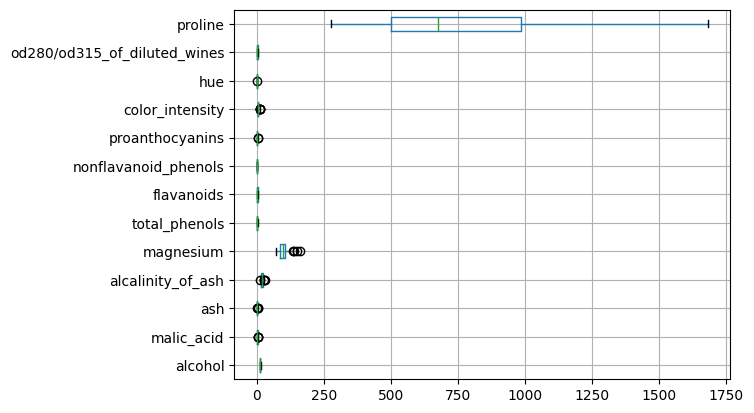

In [ ]:
# View the boxplot of our dataframe
df.boxplot(vert=False)

In [ ]:
# View the descriptive statistics of the dataframe
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


In [ ]:
# View the median of each numeric column in the dataframe
df.median(numeric_only=True)

,0
alcohol,13.050
malic_acid,1.865
ash,2.360
alcalinity_of_ash,19.500
magnesium,98.000
total_phenols,2.355
flavanoids,2.135
nonflavanoid_phenols,0.340
proanthocyanins,1.555
color_intensity,4.690


In [ ]:
# Normalise (scale) the dataframe
scaler = MinMaxScaler()  # scaler is a variable that contains methods capable of scaling the dataframe
df[['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']] = \
    scaler.fit_transform(df[['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']])

print(df)

      alcohol  malic_acid       ash  alcalinity_of_ash  magnesium  \
0    0.842105    0.191700  0.572193           0.257732   0.619565   
1    0.571053    0.205534  0.417112           0.030928   0.326087   
2    0.560526    0.320158  0.700535           0.412371   0.336957   
3    0.878947    0.239130  0.609626           0.319588   0.467391   
4    0.581579    0.365613  0.807487           0.536082   0.521739   
..        ...         ...       ...                ...        ...   
173  0.705263    0.970356  0.582888           0.510309   0.271739   
174  0.623684    0.626482  0.598930           0.639175   0.347826   
175  0.589474    0.699605  0.481283           0.484536   0.543478   
176  0.563158    0.365613  0.540107           0.484536   0.543478   
177  0.815789    0.664032  0.737968           0.716495   0.282609   

     total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
0         0.627586    0.573840              0.283019         0.593060   
1         0.575862    0.5

Normalisation is the process of placing all the variables in our dataframe on a common scale, generally between 0 and 1.
This makes it easier to compare and interpret the distribution of the data.

In the boxplot below, the dataframe has already been scaled (normalised), which allows for a clearer visualisation of the data.

<Axes: >

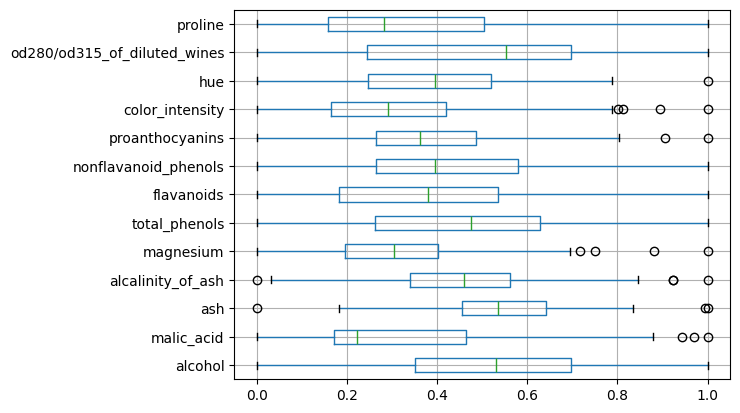

In [ ]:
# View the boxplot of our dataframe with the values already normalised (scaled)
df.boxplot(vert=False)

In [ ]:
# View the descriptive statistics of the dataframe
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,0.518584,0.315484,0.538244,0.458502,0.323278,0.453487,0.356386,0.437460,0.372523,0.322363,0.388170,0.491460,0.334446
std,0.213639,0.220780,0.146708,0.172142,0.155244,0.215811,0.210730,0.234818,0.180555,0.197806,0.185831,0.260070,0.224613
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.350658,0.170455,0.454545,0.340206,0.195652,0.262931,0.182489,0.264151,0.264984,0.165529,0.245935,0.244505,0.158702
50%,0.531579,0.222332,0.534759,0.458763,0.304348,0.474138,0.378692,0.396226,0.361199,0.290956,0.394309,0.553114,0.282097
75%,0.696711,0.462945,0.640374,0.561856,0.402174,0.627586,0.534810,0.580189,0.485804,0.419795,0.520325,0.695971,0.504280
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# View the median of each numeric column in the dataframe
df.median(numeric_only=True)

,0
alcohol,0.531579
malic_acid,0.222332
ash,0.534759
alcalinity_of_ash,0.458763
magnesium,0.304348
total_phenols,0.474138
flavanoids,0.378692
nonflavanoid_phenols,0.396226
proanthocyanins,0.361199
color_intensity,0.290956


#2. Statistical Data Analysis

# Dataset Overview

Our dataset contains 178 observations, and each observation has 13 attributes/variables.

## Alcohol
Amount of alcohol in that specific type of wine.

## Malic acid
Amount of malic acid in that specific type of wine.

## Ash
Amount of ash in that specific type of wine.

## Alcalinity of ash
Amount of ash alkalinity in that specific type of wine.

## Magnesium
Amount of magnesium in that specific type of wine.

## Total phenols
Amount of phenols in that specific type of wine.

## Flavanoids
Amount of flavanoids in that specific type of wine.

## Non-flavanoid phenols
Amount of non-flavanoid phenols in that specific type of wine.

## Proanthocyanins
Amount of proanthocyanins in that specific type of wine.

## Color intensity
Level of colour intensity in that specific type of wine.

## Hue
Hue level in that specific type of wine.

## OD280/OD315 of diluted wines
Value of diluted wine absorbance in that specific type of wine.

## Proline
Amount of proline in that specific type of wine.

##2.1. Dimensionality Reduction

Dimensionality reduction in the context of data modelling is a technique aimed at simplifying data without losing essential information. When applied before the use of clustering algorithms, such as K-means, it can be particularly useful for:

- Improving computational efficiency
- Reducing noise
- Facilitating visualisation

Next, we will reduce the dimensionality of our dataset using the Correlation Matrix.

###2.1.1. Correlation Matrix

Dimensionality reduction in the context of data modelling is a technique aimed at simplifying data without losing essential information. When applied before the use of clustering algorithms, such as K-means, it can be particularly useful for:

- Improving computational efficiency

- Reducing noise

- Facilitating visualisation

Next, we will reduce the dimensionality of our dataset using the Correlation Matrix.



In [ ]:
# View the correlation matrix for the numeric variables
df.corr()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
malic_acid,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
ash,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
alcalinity_of_ash,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
magnesium,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
total_phenols,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
flavanoids,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
nonflavanoid_phenols,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
proanthocyanins,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417
color_intensity,0.546364,0.248985,0.258887,0.018732,0.199950,-0.055136,-0.172379,0.139057,-0.025250,1.000000,-0.521813,-0.428815,0.316100


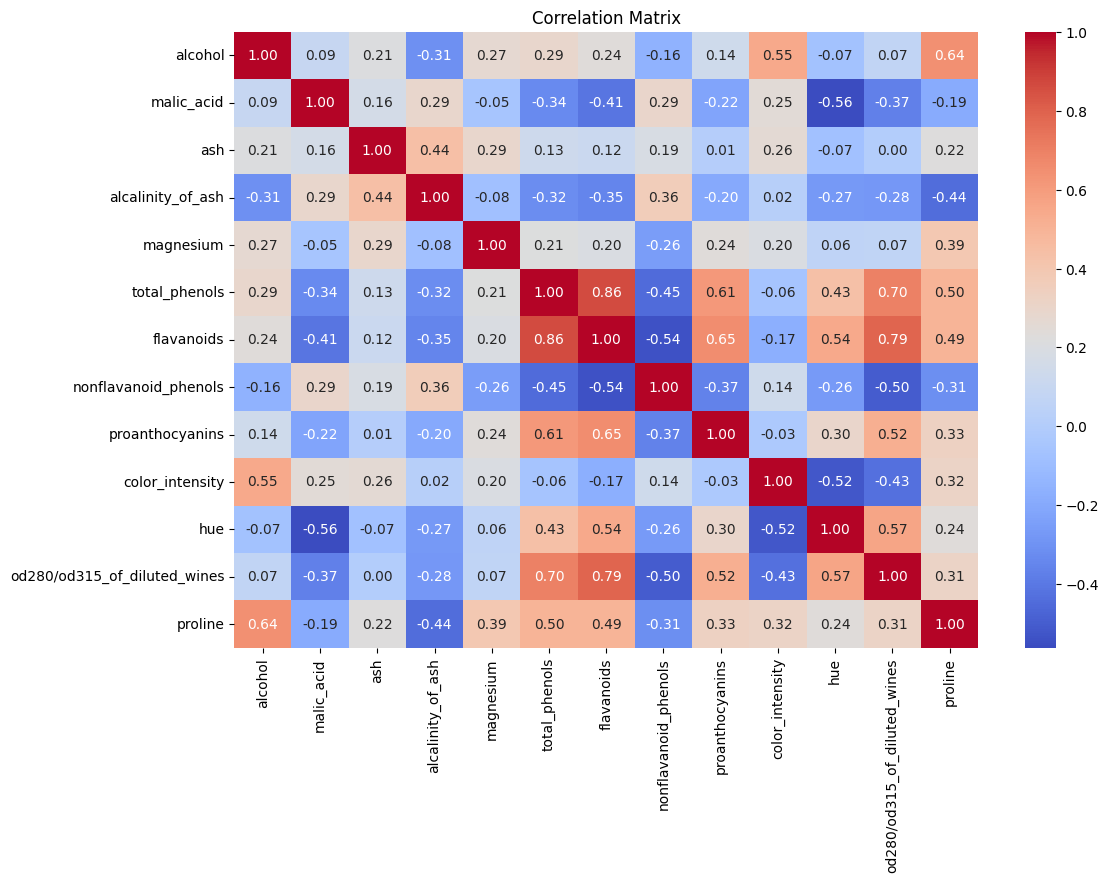

In [ ]:
# Plot the correlation matrix heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

Os cinco pares de variáveis do nosso dataset cuja correlação é mais positiva e forte são:
- total_phenols e flavanoids (com coeficiente de correlação ~=0.86)
- od280/od315_of_diluted_wines e flavanoids (~0.79)
- total_phenols e od280/od315_of_diluted_wines (~0.70)
- flavanoids e proanthocyanins (~0.65)
- proline e alchool (~0.64)              


In [ ]:
# Obtain the 5 pairs of variables with the highest positive correlation (excluding the main diagonal)
df_corr = df.corr()
top_corr = df_corr.unstack().sort_values(ascending=False)
top_corr = top_corr[top_corr != 1]  # Exclude the correlation of variables with themselves
top_10_corr = top_corr.head(10)

print(top_10_corr)

flavanoids                    total_phenols                   0.864564
total_phenols                 flavanoids                      0.864564
flavanoids                    od280/od315_of_diluted_wines    0.787194
od280/od315_of_diluted_wines  flavanoids                      0.787194
                              total_phenols                   0.699949
total_phenols                 od280/od315_of_diluted_wines    0.699949
flavanoids                    proanthocyanins                 0.652692
proanthocyanins               flavanoids                      0.652692
alcohol                       proline                         0.643720
proline                       alcohol                         0.643720
dtype: float64


Two pairs of variables that have a strong negative correlation are:
- hue and color_intensity (with a correlation coefficient of approximately -0.52)
- hue and malic_acid (with a correlation coefficient of approximately -0.56)

In [ ]:
# Obtain the 3 pairs of variables with the strongest negative correlation
df_corr = df.corr()
top_corr = df_corr.unstack().sort_values(ascending=False)
top_corr = top_corr[top_corr != 1]
top_6_corr = top_corr.tail(6)

print(top_6_corr)

hue                   color_intensity        -0.521813
color_intensity       hue                    -0.521813
nonflavanoid_phenols  flavanoids             -0.537900
flavanoids            nonflavanoid_phenols   -0.537900
malic_acid            hue                    -0.561296
hue                   malic_acid             -0.561296
dtype: float64


Upon examining the correlation matrix, we can identify the most significant correlations between the variables.

Variables that are highly correlated with each other, such as 'total_phenols' and 'flavanoids', may contain redundant information. Therefore, we chose to retain only one of them. This helps reduce the dimensionality of the dataset while preserving the essential information.

<Axes: >

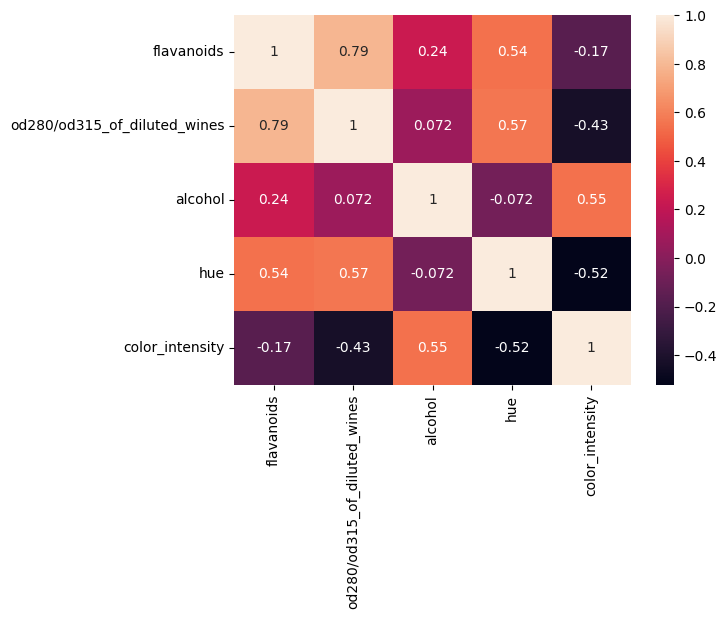

In [ ]:
# Draw a heatmap of the correlations between the numeric variables that are most significant for our analysis
df_corr_vars = ['flavanoids', 'od280/od315_of_diluted_wines', 'alcohol', 'hue', 'color_intensity']
df_corr_matrix = df[df_corr_vars].corr()
sns.heatmap(df_corr_matrix, annot=True)

#3. Data Modelling


The K-Means algorithm is a clustering technique used to group unlabelled data into distinct clusters based on similar characteristics.

By using K-Means, WineNot will be able to identify purchasing patterns, preferences for specific types of wine, preferred price ranges, and other relevant factors. This analysis provides the wine shop with valuable insights that can be used to adjust marketing strategies, stock management, and customer service in order to meet the needs of each customer segment more effectively.

In summary, K-Means is a strategic tool that enables WineNot to improve the effectiveness of its marketing and sales actions, helping to optimise the profitability of the business by offering a more personalised and targeted approach to its customers.

For the modelling of our data, we chose to use only 6 of the variables whose correlations are the most significant.

In [ ]:
# Create a dataframe called df_km containing only the numeric variables to be used for segmentation
vars_to_model = ['flavanoids', 'od280/od315_of_diluted_wines', 'alcohol', 'hue', 'color_intensity']
df_km = df[vars_to_model]
df_km

,flavanoids,od280/od315_of_diluted_wines,alcohol,hue,color_intensity
0,0.573840,0.970696,0.842105,0.455285,0.372014
1,0.510549,0.780220,0.571053,0.463415,0.264505
2,0.611814,0.695971,0.560526,0.447154,0.375427
3,0.664557,0.798535,0.878947,0.308943,0.556314
4,0.495781,0.608059,0.581579,0.455285,0.259386
...,...,...,...,...,...
173,0.056962,0.172161,0.705263,0.130081,0.547782
174,0.086498,0.106227,0.623684,0.178862,0.513652
175,0.073840,0.106227,0.589474,0.089431,0.761092
176,0.071730,0.128205,0.563158,0.097561,0.684300


## 3.1. Elbow Curve


The definition of the appropriate number of clusters for our data model can be determined using the Elbow Curve method.

This method calculates the error for the K-means model trained with different numbers of clusters, and then plots that relationship.

The region where the curve shows the greatest inflection (the "elbow") suggests an ideal number of clusters.

Note: the error (or inertia) can be measured by the sum of the distances from each observation to its centroid.


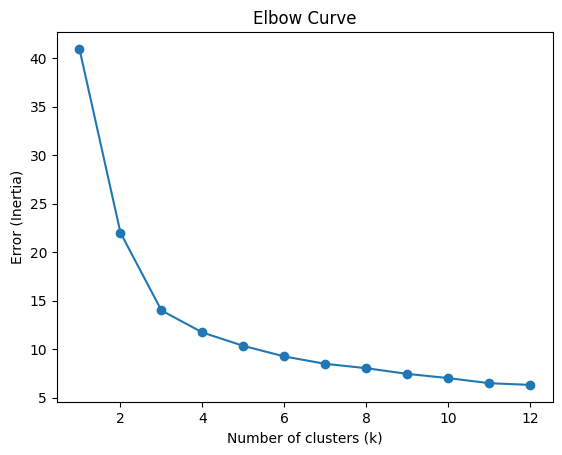

In [ ]:
# Create a list containing the inertia for each tested cluster value.
# These values can be used to determine the ideal number of clusters through the Elbow Method analysis.
list_errors = []
range_clusters = range(1, 13)

for k in range_clusters:
    model_kmeans_elbow = KMeans(n_clusters=k, random_state=1, n_init=10)
    model_kmeans_elbow.fit(df_km)
    list_errors.append(model_kmeans_elbow.inertia_)

# Generate the Elbow Curve, which will help us decide the ideal number of clusters.
# The higher the number of clusters, the lower the inertia/error percentage.
plt.plot(range_clusters, list_errors, marker='o')
plt.title('Elbow Curve')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Error (Inertia)')
plt.show()

The analysis of this graph allows us to conclude that the ideal number of clusters to use in the K-means model is 4 clusters (corresponding to the region where the curve shows the greatest inflection, the "elbow").


##3.2.K-means

In [ ]:
# Create a variable to calculate a K-means model with 4 clusters
model_kmeans = KMeans(n_clusters = 4, random_state=0)

# Run the K-means algorithm for the dataframe
clusters = model_kmeans.fit_predict(df_km)

# The result of fit_predict is an array with the size of the dataset, indicating the cluster to which each observation belongs
clusters

array([2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3,
       2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 1, 0, 3, 0, 0,
       2, 3, 0, 0, 0, 2, 2, 2, 3, 0, 0, 0, 0, 3, 0, 3, 0, 1, 3, 0, 0, 0,
       0, 3, 0, 0, 0, 3, 3, 0, 0, 0, 3, 0, 0, 0, 3, 0, 3, 3, 3, 0, 3, 3,
       3, 3, 0, 0, 3, 0, 3, 3, 1, 3, 3, 3, 3, 3, 3, 3, 3, 0, 3, 3, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1], dtype=int32)

In [ ]:
# Adicionar o vector com os clusters ao dataset
df['clusters_km'] = clusters
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clusters_km
0,0.842105,0.191700,0.572193,0.257732,0.619565,0.627586,0.573840,0.283019,0.593060,0.372014,0.455285,0.970696,0.561341,2
1,0.571053,0.205534,0.417112,0.030928,0.326087,0.575862,0.510549,0.245283,0.274448,0.264505,0.463415,0.780220,0.550642,2
2,0.560526,0.320158,0.700535,0.412371,0.336957,0.627586,0.611814,0.320755,0.757098,0.375427,0.447154,0.695971,0.646933,2
3,0.878947,0.239130,0.609626,0.319588,0.467391,0.989655,0.664557,0.207547,0.558360,0.556314,0.308943,0.798535,0.857347,2
4,0.581579,0.365613,0.807487,0.536082,0.521739,0.627586,0.495781,0.490566,0.444795,0.259386,0.455285,0.608059,0.325963,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,0.705263,0.970356,0.582888,0.510309,0.271739,0.241379,0.056962,0.735849,0.205047,0.547782,0.130081,0.172161,0.329529,1
174,0.623684,0.626482,0.598930,0.639175,0.347826,0.282759,0.086498,0.566038,0.315457,0.513652,0.178862,0.106227,0.336662,1
175,0.589474,0.699605,0.481283,0.484536,0.543478,0.210345,0.073840,0.566038,0.296530,0.761092,0.089431,0.106227,0.397290,1
176,0.563158,0.365613,0.540107,0.484536,0.543478,0.231034,0.071730,0.754717,0.331230,0.684300,0.097561,0.128205,0.400856,1


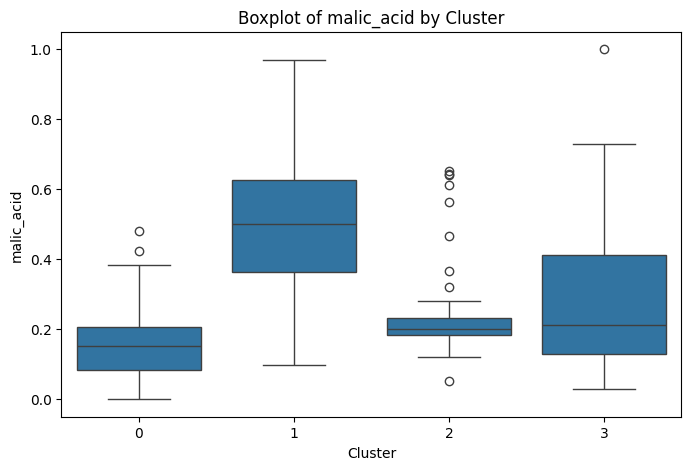

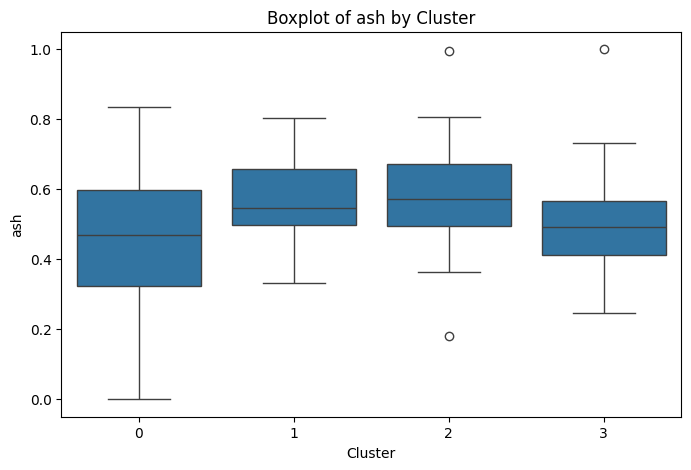

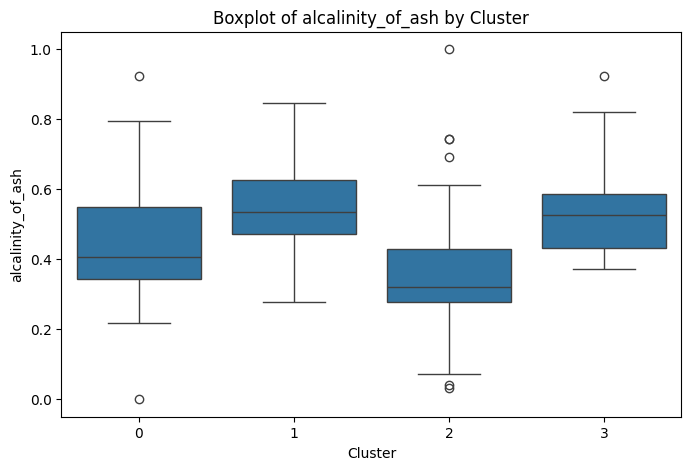

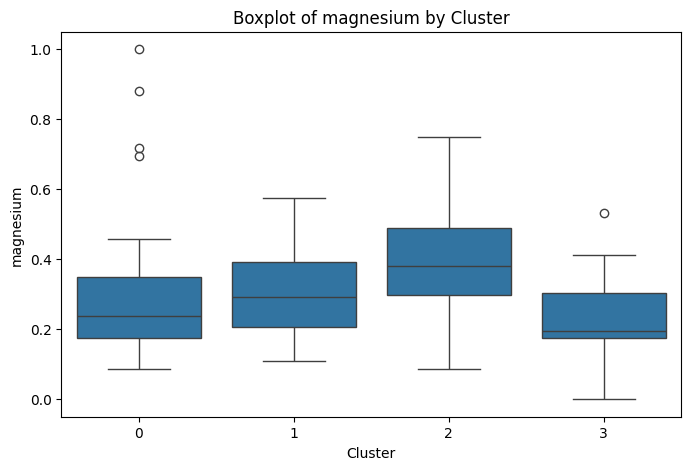

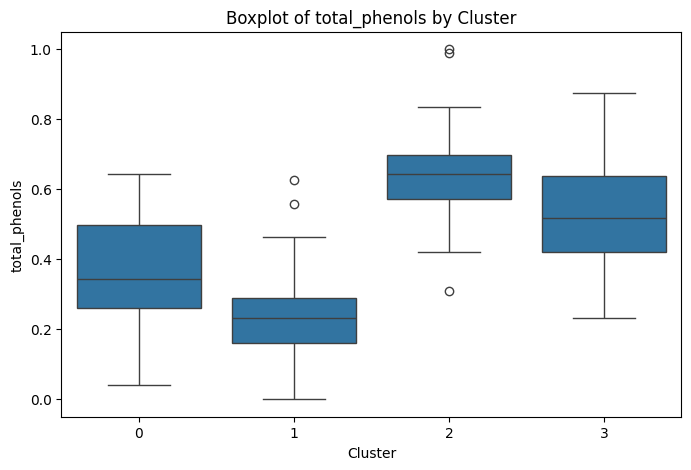

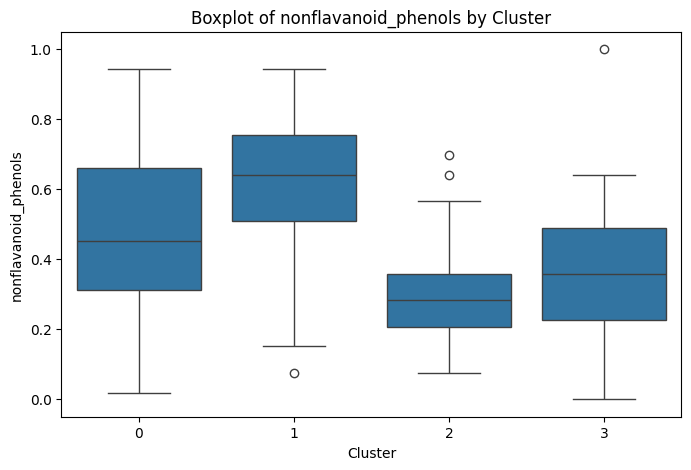

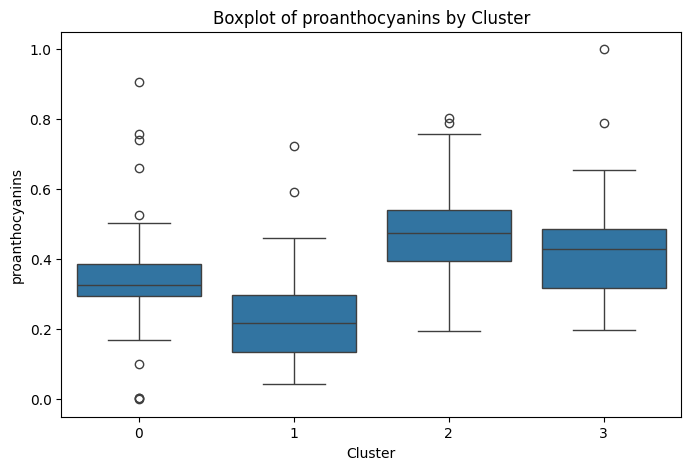

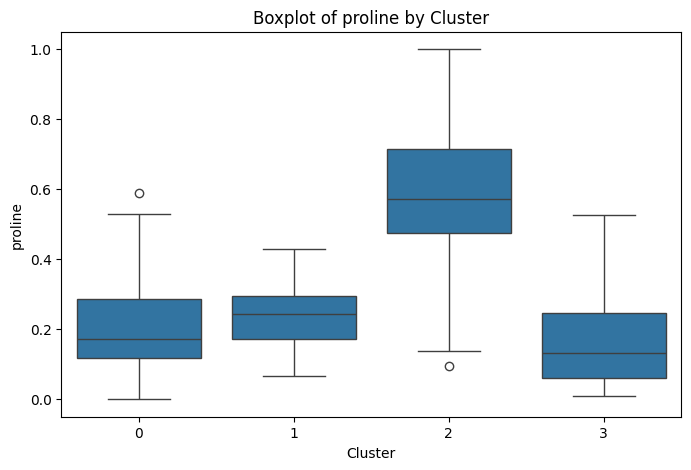

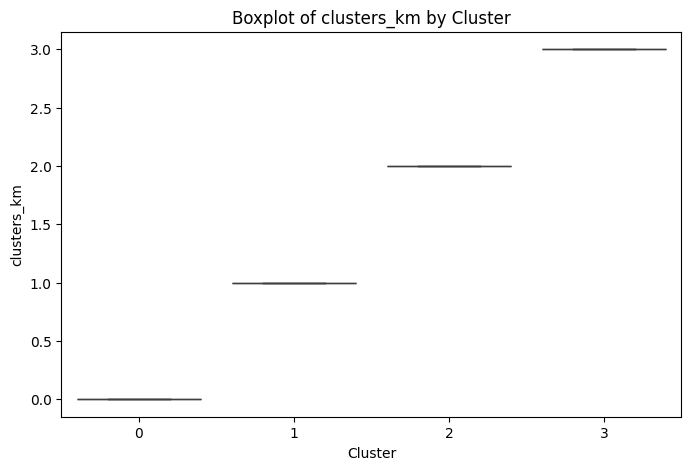

In [ ]:
# Add the cluster labels to the original dataframe
df_with_clusters = df.copy()
df_with_clusters['cluster'] = clusters

# Select the remaining numeric variables not used in the clustering model
remaining_vars = [col for col in df.select_dtypes(include=['number']).columns if col not in vars_to_model]

# Plot one boxplot per remaining variable, grouped by cluster
for var in remaining_vars:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_with_clusters, x='cluster', y=var)
    plt.title(f'Boxplot of {var} by Cluster')
    plt.xlabel('Cluster')
    plt.ylabel(var)
    plt.show()

In [ ]:
# View descriptive statistics for all clusters in a single table
df_with_clusters.groupby('cluster').describe()

alcohol                                                              \
          count      mean       std       min       25%       50%       75%   
cluster                                                                       
0          35.0  0.321203  0.145780  0.000000  0.210526  0.310526  0.396053   
1          51.0  0.553715  0.137330  0.307895  0.460526  0.547368  0.648684   
2          59.0  0.721320  0.114573  0.515789  0.646053  0.718421  0.807895   
3          33.0  0.311164  0.109020  0.110526  0.244737  0.331579  0.365789   

                  malic_acid            ...   proline           clusters_km  \
              max      count      mean  ...       75%       max       count   
cluster                                 ...                                   
0        0.694737       35.0  0.163806  ...  0.286733  0.589872        35.0   
1        0.871053       51.0  0.507363  ...  0.293866  0.429387        51.0   
2        1.000000       59.0  0.242078  ...  0.714693  1.000000        59.0   
3        0.531579       33.0  0.311055  ...  0.247504  0.525678        33.0   

                                            
        mean  std  min  25%  50%  75%  max  
cluster                                     
0        0.0  0.0  0.0  0.0  0.0  0.0  0.0  
1        1.0  0.0  1.0  1.0  1.0  1.0  1.0  
2        2.0  0.0  2.0  2.0  2.0  2.0  2.0  
3        3.0  0.0  3.0  3.0  3.0  3.0  3.0  

[4 rows x 112 columns]

##3.2.1 PCA Analysis:

Principal Component 1 is characterised by a significant positive loading on od280/od315_of_diluted_wines and color_intensity, and by a significant negative loading on hue and flavanoids. This suggests that clusters with high values on this component tend to have high values of od280/od315_of_diluted_wines and color_intensity, and low values of hue and flavanoids, while low values on this component indicate the opposite.

Principal Component 2 is characterised by a significant positive loading on flavanoids, alcohol, and color_intensity, and a significant negative loading on hue.

Taking this into account, we can understand that:

⦁ Cluster 0 has high values on Principal Component 2 and low values on Principal Component 1. It is characterised by wines with lower flavanoids content and higher od280/od315_of_diluted_wines and hue values.

⦁ Cluster 1 has high values on Principal Component 1 and low values on Principal Component 2. It is characterised by wines with higher flavanoids content, lower od280/od315_of_diluted_wines, and a more intense hue, which may indicate characteristics associated with younger or lower-quality wines, as interpreted by PC1.

⦁ Cluster 2 has low values on both principal components. It is characterised by wines with high color_intensity and high alcohol content.

⦁ Cluster 3 has high values on both principal components. It shows medium values of alcohol and color_intensity, according to PC2, and has intermediate characteristics in relation to the variables that are most influential in PC1.


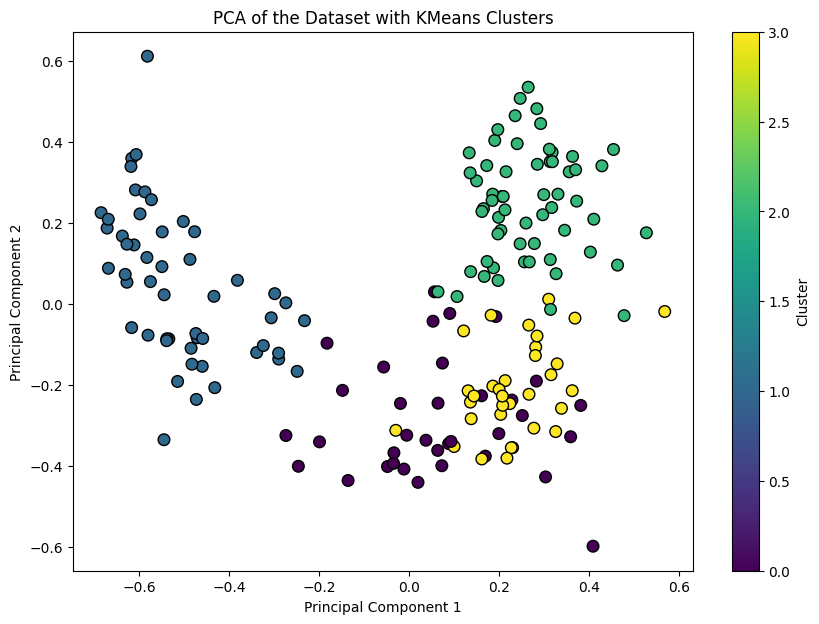

In [ ]:
# Apply PCA for dimensionality reduction to 2 components
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df_km)

# Visualise the clusters using PCA
plt.figure(figsize=(10, 7))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=clusters, cmap='viridis', marker='o', edgecolor='k', s=70)
plt.title('PCA of the Dataset with KMeans Clusters')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(label='Cluster')
plt.show()

In [ ]:
# Define Components
loadings = pca.components_.T
df_loadings = pd.DataFrame(loadings, columns=['PC1', 'PC2'], index=df_km.columns)

print("Principal Component Loadings:")
print(df_loadings)

print("\nSignificant loadings for PC1:")
print(df_loadings['PC1'].abs().sort_values(ascending=False))

Principal Component Loadings:
                                   PC1       PC2
flavanoids                    0.508309  0.283175
od280/od315_of_diluted_wines  0.696822  0.108961
alcohol                      -0.001591  0.767653
hue                           0.398117 -0.115730
color_intensity              -0.312348  0.552498

Significant loadings for PC1:
od280/od315_of_diluted_wines    0.696822
flavanoids                      0.508309
hue                             0.398117
color_intensity                 0.312348
alcohol                         0.001591
Name: PC1, dtype: float64


We can also attempt to obtain the percentage distribution of each cluster. In the code block below, we observe that:

- Cluster 2 contains approximately 35.39% of the observations.
- Cluster 0 contains approximately 33.15% of the observations.
- Cluster 1 contains approximately 16.29% of the observations.
- Cluster 3 contains approximately 15.17% of the observations.

This means that Cluster 2 is the largest group, followed by Clusters 0, 1, and 3, respectively.

In [ ]:
# Obtain the size of the clusters as a percentage
df['clusters_km'].value_counts(normalize=True) * 100

,proportion
clusters_km,
2,33.146067
1,28.651685
0,19.662921
3,18.539326


In [ ]:
# View descriptive statistics for the observations in Cluster 2
df[df['clusters_km'] == 2].describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,clusters_km
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000,59.0
mean,0.721320,0.242078,0.580350,0.352874,0.394436,0.649445,0.560752,0.297729,0.474576,0.361601,0.478021,0.693177,0.578882,2.0
std,0.114573,0.130019,0.131246,0.171758,0.133614,0.120955,0.084898,0.134747,0.131323,0.108039,0.102736,0.124141,0.186682,0.0
min,0.515789,0.053360,0.181818,0.030928,0.086957,0.310345,0.316456,0.075472,0.195584,0.176621,0.276423,0.476190,0.094151,2.0
25%,0.646053,0.182806,0.494652,0.278351,0.298913,0.570690,0.501055,0.207547,0.394322,0.287543,0.406504,0.586081,0.475749,2.0
50%,0.718421,0.201581,0.572193,0.319588,0.380435,0.644828,0.556962,0.283019,0.476341,0.351536,0.479675,0.695971,0.572040,2.0
75%,0.807895,0.231225,0.671123,0.430412,0.489130,0.696552,0.612869,0.358491,0.539432,0.421928,0.528455,0.780220,0.714693,2.0
max,1.000000,0.652174,0.994652,1.000000,0.750000,1.000000,0.757384,0.698113,0.804416,0.650171,0.715447,1.000000,1.000000,2.0


In [ ]:
# Obtain the coordinates of the cluster centroids
cluster_centroids = model_kmeans.cluster_centers_
cluster_centroids

array([[0.30440024, 0.44866562, 0.32120301, 0.55554007, 0.14785471],
       [0.10101762, 0.15628816, 0.55371517, 0.17232584, 0.50808071],
       [0.56075234, 0.69317688, 0.72132025, 0.47802122, 0.3616012 ],
       [0.44080041, 0.69419469, 0.31116427, 0.38359202, 0.15027407]])

<Axes: xlabel='flavanoids', ylabel='alcohol'>

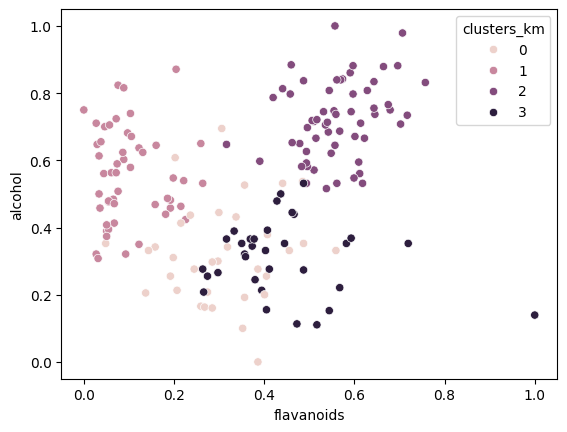

In [ ]:
# Visualise the distribution of the variables flavanoids and alcohol for each cluster in a scatter plot
sns.scatterplot(x=df["flavanoids"], y=df["alcohol"], hue=df['clusters_km'])

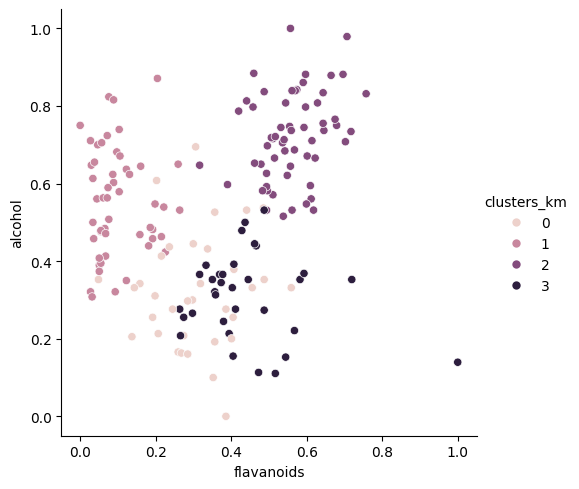

In [ ]:
sns.relplot(x="flavanoids", y="alcohol", hue="clusters_km", data = df)

<Axes: xlabel='flavanoids', ylabel='color_intensity'>

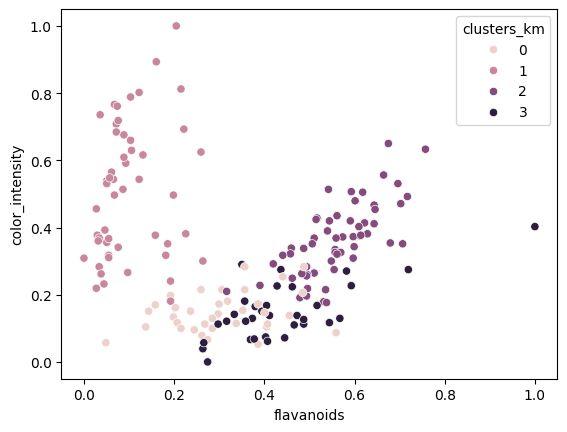

In [ ]:
sns.scatterplot(x = df["flavanoids"], y = df["color_intensity"], hue = df['clusters_km'])

Next, we will create a pairplot to demonstrate the relationship between the variables 'flavanoids', 'od280/od315_of_diluted_wines', and 'alcohol', distinguished by wine colour intensity ('color_intensity') categorised as 'low', 'medium', and 'high'.

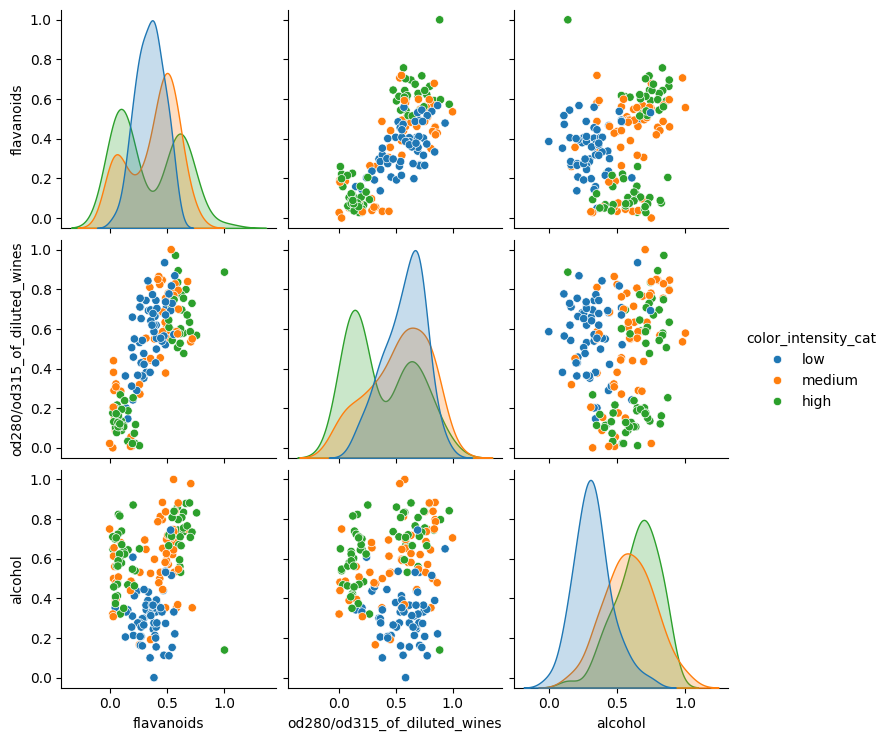

In [ ]:
# Plot all distributions and densities between the variables 'flavanoids', 'od280/od315_of_diluted_wines', and 'alcohol', differentiated by 'color_intensity'

# Categorise the variable 'color_intensity' using quantiles
quantiles = df['color_intensity'].quantile([0.33, 0.66])

# Create the categories
df['color_intensity_cat'] = pd.cut(
    df['color_intensity'],
    bins=[-float('inf'), quantiles[0.33], quantiles[0.66], float('inf')],
    labels=['low', 'medium', 'high']
)

sns.pairplot(
    df[['flavanoids', 'od280/od315_of_diluted_wines', 'alcohol', 'color_intensity_cat']],
    diag_kind='kde',
    hue='color_intensity_cat'
)

On the diagonal axis of the pairplot, we have density plots for each variable, showing the distribution of the measurements for each category of 'color_intensity_cat'. For example, the density plot for 'flavanoids' shows that measurements with high colour intensity tend to have lower values of 'flavanoids'. In the remaining plots (scatter plots), we can observe how each pair of variables relates to one another for each category of colour intensity.

The analysis of this set of plots can help us identify whether there are visible correlations between wine colour intensity and other chemical characteristics. Conclusions drawn:

- Wines with high colour intensity tend to have lower values of flavanoids.
- There is a visible separation in the plot relating 'od280/od315_of_diluted_wines' and 'flavanoids', suggesting that these two compounds may have an inverse relationship, especially for wines with high colour intensity.
- The scatter plots between 'alcohol' and the other two chemical variables appear to show a more homogeneous distribution across the 'color_intensity' categories, which may indicate that the relationship between alcohol content and colour intensity is not as strong, or is more complex than a simple linear pattern.

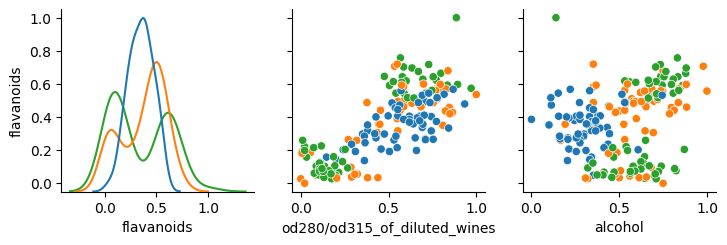

In [ ]:
# Use the x_vars and y_vars parameters to display only specific parts of a PairGrid plot
my_plot4 = sns.PairGrid(
    data=df[['flavanoids', 'od280/od315_of_diluted_wines', 'alcohol', 'color_intensity_cat']],
    hue='color_intensity_cat',
    x_vars=['flavanoids', 'od280/od315_of_diluted_wines', 'alcohol'],
    y_vars=['flavanoids']
)

my_plot4.map_offdiag(sns.scatterplot)
my_plot4.map_diag(sns.kdeplot)

## 3.3. Silhouette Plot

The Silhouette Plot is a visual technique used to interpret the validity of clusters in the context of a clustering analysis.

The Silhouette Coefficient represents the relationship between intra-cluster distances (the distance from points within a cluster to their centroid) and inter-cluster distances (between clusters). This coefficient can vary between -1 and 1, where:
- 1 represents a perfect segmentation
- 0 represents a segmentation with no meaningful structure
- -1 represents an incorrect segmentation

In the plot below, we can observe that the 4 previously defined clusters contain a good number of positive values, suggesting a good clustering structure. All clusters have values above the average silhouette score (the red dashed line), which suggests that most observations are closer to their own cluster than to the others.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


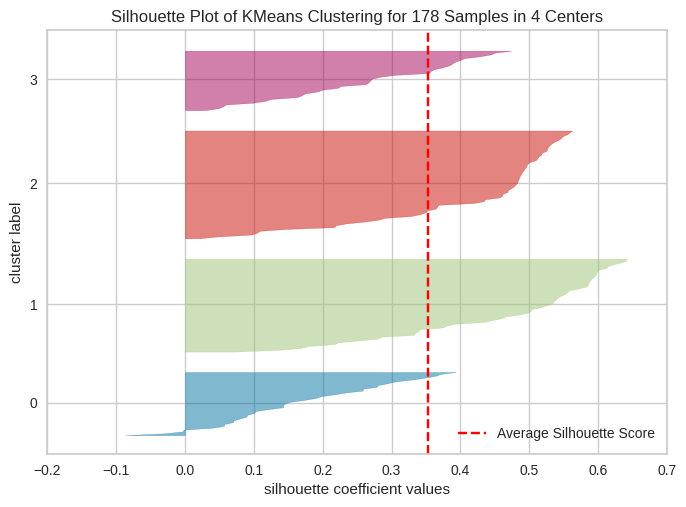

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 178 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# Plot the silhouette plot for 4 clusters
from yellowbrick.cluster import SilhouetteVisualizer
visualizer = SilhouetteVisualizer(model_kmeans, colors='yellowbrick')
visualizer.fit(df_km)
visualizer.show()

##3.4. Self-Organizing Maps

Self-Organizing Maps (SOMs) are an unsupervised learning technique that aims to map high-dimensional data into a two-dimensional representation while preserving the topological relationships between the data.

In [ ]:
# df_som is a new DataFrame that contains only the columns listed in vars_to_model from the original DataFrame df.
df_som = df[vars_to_model]
df_som

,flavanoids,od280/od315_of_diluted_wines,alcohol,hue,color_intensity
0,0.573840,0.970696,0.842105,0.455285,0.372014
1,0.510549,0.780220,0.571053,0.463415,0.264505
2,0.611814,0.695971,0.560526,0.447154,0.375427
3,0.664557,0.798535,0.878947,0.308943,0.556314
4,0.495781,0.608059,0.581579,0.455285,0.259386
...,...,...,...,...,...
173,0.056962,0.172161,0.705263,0.130081,0.547782
174,0.086498,0.106227,0.623684,0.178862,0.513652
175,0.073840,0.106227,0.589474,0.089431,0.761092
176,0.071730,0.128205,0.563158,0.097561,0.684300


In [ ]:
# Build a network of 8x8 neurons
model_som = sps.SOMNet(net_height = 8, net_width = 8, data = df_som, init='random', random_seed=8)

Periodic Boundary Conditions inactive.
The weights will be initialized randomly.


In [ ]:
# Training the model
model_som.train()

The map will be trained with the batch algorithm.
Training SOM... done!


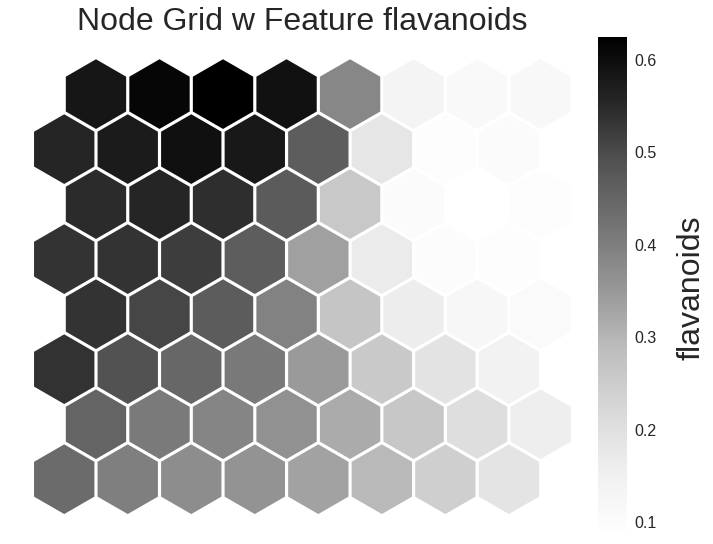

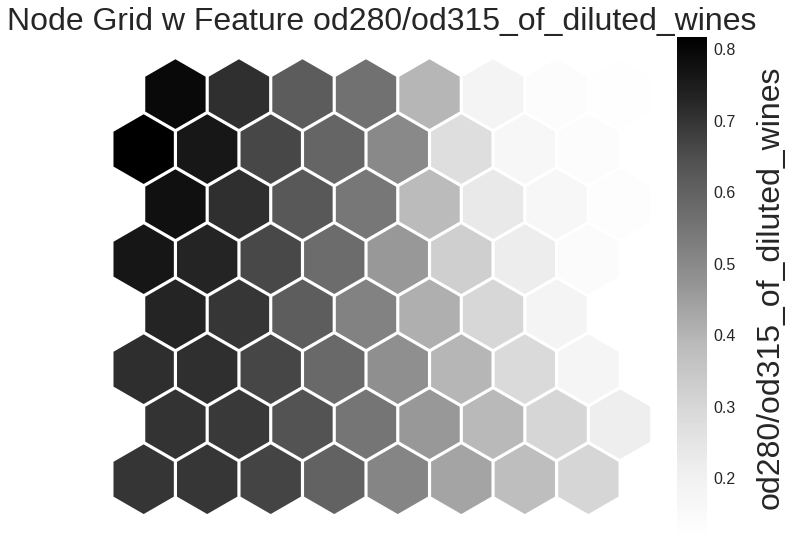

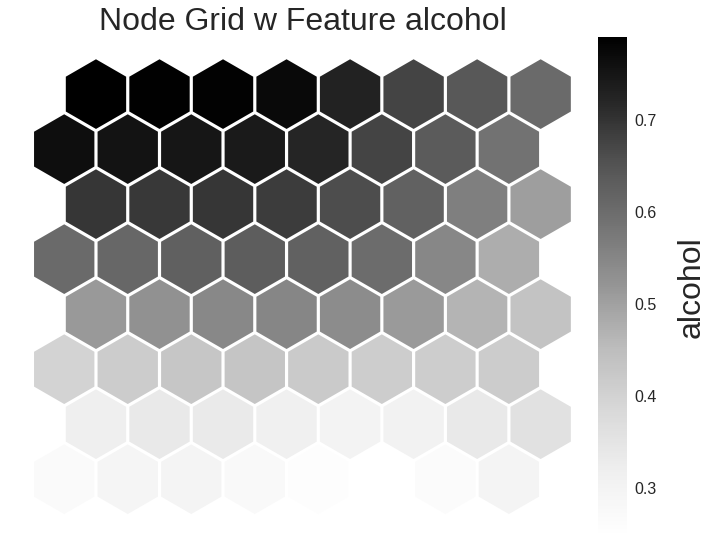

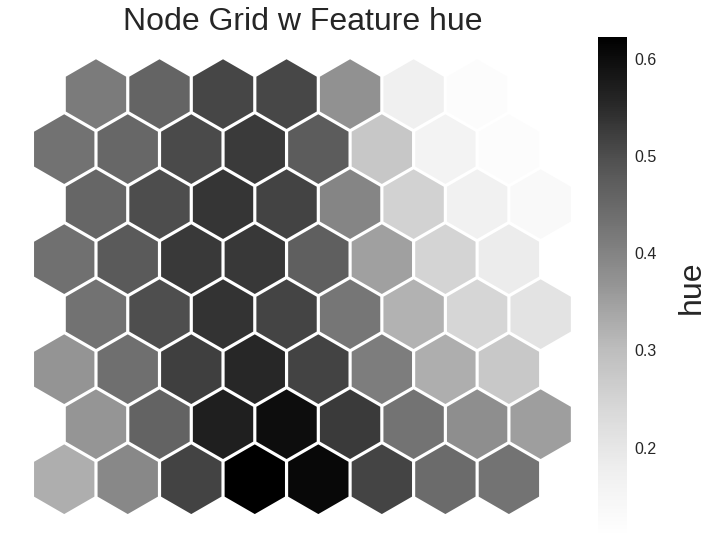

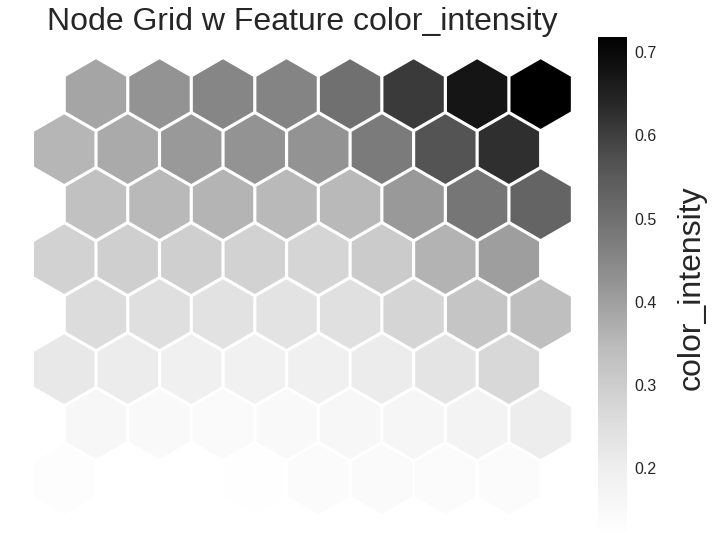

In [ ]:
# View the maps for each of the variables in our model
for position, var_name in enumerate(vars_to_model):
    fig = model_som.nodes_graph(colnum=position, colname=var_name)


# 4. Cluster Interpretation

## 4.1. Decision Tree

The decision tree helps determine the most influential characteristics in defining the clusters formed by K-means.

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [ ]:
X = df[['proline', 'flavanoids', 'od280/od315_of_diluted_wines', 'total_phenols']]
y = df['clusters_km']

In [ ]:
# Initialise and train the decision tree
tree = DecisionTreeClassifier(random_state=0)
tree.fit(X, y)

tree_limited_depth = DecisionTreeClassifier(max_depth=3, random_state=0)
tree_limited_depth.fit(X, y)

DecisionTreeClassifier(max_depth=3, random_state=0)

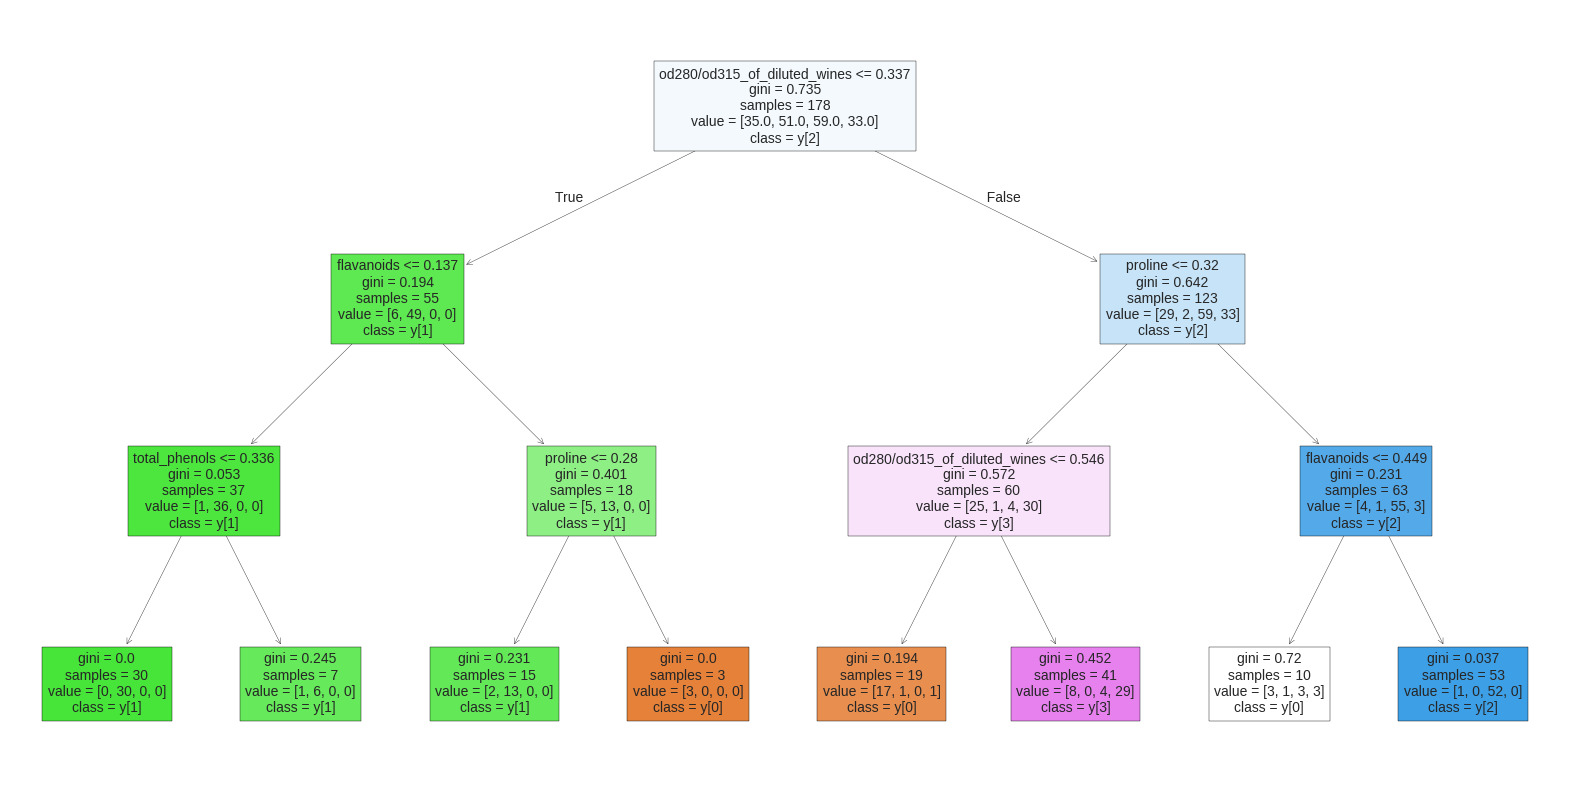

In [ ]:
# Create a decision tree and limit its depth, which can help make the analysis simpler and easier to interpret.
chosen_tree = tree_limited_depth
plt.figure(figsize=(20, 10))
plot_tree(chosen_tree, filled=True, feature_names=X.columns, class_names=True, fontsize=10)
plt.show()

Conclusions drawn from the creation and training of the decision tree:

- Flavanoids appear as the first splitting criterion in the tree, which suggests that they are a strong indicator for differentiating the various types of wine.

- On the other side of the branching structure, we have proline, which also serves as a splitting criterion. This indicates that its levels are also relevant for separating the clusters.

- OD280/OD315 of diluted wines: this ratio is used in multiple splits throughout the tree, which suggests that the protein stability of the wines, related to this ratio, is a distinguishing characteristic between the clusters.

## 4.2. ChatGPT Survey

The integration of OpenAI with Python is a process that makes it possible to use language models developed by OpenAI, such as ChatGPT, through an API. The purpose of the code in this notebook is to use the integration with ChatGPT to obtain a description of the clusters identified in K-means and to create marketing strategies that support the increase of wine sales.

Note: This code will only work if a valid OpenAI API key is provided. Without an active and properly configured API key, the request to the API cannot be completed.

In [ ]:
# Create a function that sends a text to ChatGPT and returns its response
chatgpt_messages = []
def get_completion(prompt, model="gpt-3.5-turbo"):
    # Initialize the OpenAI client inside the function
    # It's crucial to replace 'YOUR_API_KEY_HERE' with the actual API key
    client = openai.OpenAI(api_key='YOUR_API_KEY_HERE') # Make sure to replace this line with your actual API key

    chatgpt_messages.append({"role": "user", "content": prompt})
    response = client.chat.completions.create( # Use the client instance
        model=model,
        messages=chatgpt_messages,
        temperature=0,
    )
    chatgpt_messages.append(response.choices[0].message)
    return response.choices[0].message.content

In [ ]:
# Ask ChatGPT to describe our clusters and print its response
def get_prompt(x):
    return x

clusters = df_km.apply(lambda x: get_prompt(x))
print(get_completion("Describe the 4 clusters in my dataframe (Cluster 0, Cluster 1, Cluster 2 and Cluster 3), and give each of them a name." + str(clusters)))

TypeError: Client.__init__() got an unexpected keyword argument 'proxies'

In [ ]:
print(get_completion("What marketing strategies are most effective for each cluster?"))

TypeError: Client.__init__() got an unexpected keyword argument 'proxies'

In [ ]:
print(get_completion("How can we personalise our product to meet the specific needs of each cluster?"))

# 5. Iterative K-means



To conclude our work, we will iteratively run the K-means algorithm, showing the movement of the centroids and the formation of the 4 clusters throughout the iterations. For this specific analysis, we are using only the variables color_intensity and flavanoids.

In [ ]:
X = df[vars_to_model].values
scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

# Calculate the Euclidean distance
def calculate_distance(X, centroids):
    return np.sqrt(((X - centroids[:, np.newaxis])**2).sum(axis=2))

# Update the centroids
def update_centroids(X, labels, K):
    centroids = np.array([X[labels == k].mean(axis=0) for k in range(K)])
    return centroids

# Initialise K-means
np.random.seed(42)
centroids = X_normalized[np.random.choice(range(len(X_normalized)), 4, replace=False)]  # Choosing random centroids from the data

# Prepare the visualisation and add the points to the plot
fig = go.Figure()
frames = []
fig.add_trace(go.Scatter(x=X_normalized[:, 0], y=X_normalized[:, 1], mode='markers', name='Points',
                         marker=dict(color='lightgrey', size=7, opacity=0.5)))

# Initialise the centroids in the plot
fig.add_trace(go.Scatter(x=centroids[:, 0], y=centroids[:, 1], mode='markers', name='Centroids',
                         marker=dict(color='red', size=10, line=dict(color='black', width=2))))

# Run K-means manually and generate the frames
for i in range(10):  # Number of iterations
    distances = calculate_distance(X_normalized, centroids)
    labels = np.argmin(distances, axis=0)
    new_centroids = update_centroids(X_normalized, labels, 4)

    # Create frames with points and centroids
    frame_data = [
        go.Scatter(x=X_normalized[:, 0], y=X_normalized[:, 1], mode='markers', name='Points',
                   marker=dict(color=labels, size=7, colorscale='Viridis', opacity=0.5)),
        go.Scatter(x=new_centroids[:, 0], y=new_centroids[:, 1], mode='markers', name='Centroids',
                   marker=dict(color='red', size=10, line=dict(color='black', width=2)))
    ]
    frames.append(go.Frame(data=frame_data, name=f'Frame {i}'))
    centroids = new_centroids

fig.frames = frames

fig.update_layout(
    updatemenus=[{
        'type': 'buttons',
        'buttons': [{
            'label': 'Play',
            'method': 'animate',
            'args': [None, {'frame': {'duration': 1000, 'redraw': True}, 'fromcurrent': True}],
        }, {
            'label': 'Pause',
            'method': 'animate',
            'args': [[None], {'frame': {'duration': 0, 'redraw': False}, 'mode': 'immediate', 'transition': {'duration': 0}}],
        }]
    }],
    title='Iterative K-means: Centroid Movement and Cluster Formation',
    xaxis=dict(title='Flavanoids'),
    yaxis=dict(title='Color Intensity')
)

fig.show()